In [1]:
from typing import List, Tuple
import pandas as pd
import polars as pl
import numpy as np

from sklearn.base import TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Polygon

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

In [2]:
df = pl.read_csv('nba_api_code/nba_shots_pbp.csv')
df.head(5)

gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON
i64,i64,str,i64,i64,str,i64,str,str,i64,i64,i64,str,i64,f64,f64,i64,str,str,str,str,i64,i64,i64,i64,f64,str,f64,str,str,str,str
21000001,2,"""PT11M43.00S""",1,1610612738,"""BOS""",406,"""O'Neal""","""S. O'Neal""",-4,11,1,"""Missed""",1,null,null,0,"""h""","""MISS S. O'Neal 1' Layup""","""Missed Shot""","""Layup Shot""",0,2,3,21000001,1.6106e9,"""BOS""",1.6106e9,"""MIA""",null,null,"""2010-11"""
21000001,8,"""PT10M53.00S""",1,1610612748,"""MIA""",2544,"""James""","""L. James""",144,135,20,"""Made""",1,0.0,2.0,2,"""v""","""James 20' Pullup Jump Shot (2 …","""Made Shot""","""Pullup Jump shot""",0,2,9,21000001,1.6106e9,"""BOS""",1.6106e9,"""MIA""",null,null,"""2010-11"""
21000001,9,"""PT10M35.00S""",1,1610612738,"""BOS""",1718,"""Pierce""","""P. Pierce""",165,83,18,"""Missed""",1,null,null,0,"""h""","""MISS Pierce 18' Step Back Jump…","""Missed Shot""","""Step Back Jump shot""",0,2,10,21000001,1.6106e9,"""BOS""",1.6106e9,"""MIA""",null,null,"""2010-11"""
21000001,11,"""PT10M27.00S""",1,1610612748,"""MIA""",2548,"""Wade""","""D. Wade""",21,7,2,"""Missed""",1,null,null,0,"""v""","""MISS Wade 2' Driving Layup""","""Missed Shot""","""Driving Layup Shot""",0,2,12,21000001,1.6106e9,"""BOS""",1.6106e9,"""MIA""",null,null,"""2010-11"""
21000001,14,"""PT10M02.00S""",1,1610612748,"""MIA""",2544,"""James""","""L. James""",-152,107,19,"""Missed""",1,null,null,0,"""v""","""MISS James 19' Jump Shot""","""Missed Shot""","""Jump Shot""",0,2,16,21000001,1.6106e9,"""BOS""",1.6106e9,"""MIA""",null,null,"""2010-11"""


In [3]:
df.shape

(3290211, 32)

In [4]:
# ripped from stackoverflow
def draw_court_on_ax(ax, backboard_angle=150):
    ax.plot([-250, 250], [-40, -40], 'k-', zorder=2)
    ax.plot([-250, 250], [470, 470], 'k-', zorder=2)
    ax.plot([-250, -250], [-40, 470], 'k-', zorder=2)
    ax.plot([250, 250], [-40, 470], 'k-', zorder=2)
    ax.plot([-30, 30], [-10, -10], 'k-', zorder=2)
    ax.plot([-60, -60], [-40, 150], 'k-', zorder=2)
    ax.plot([60, 60], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, -80], [-40, 150], 'k-', zorder=2)
    ax.plot([80, 80], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, 80], [150, 150], 'k-', zorder=2)
    ax.plot([220, 220], [-40, 90], 'k-', zorder=2)
    ax.plot([-220, -220], [-40, 90], 'k-', zorder=2)
    three_point = Arc((0, 0),   width=475, height=475, theta1=22,  theta2=158, linewidth=1.5, zorder=2)
    top_key = Arc((0, 150), width=120, height=120, theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    bottom_key = Arc((0, 150), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, linestyle='--', zorder=2)
    basket = Arc((0, 0),   width=15,  height=15,  theta1=0,   theta2=360, linewidth=1.5, zorder=2)
    restricted = Arc((0, 7.5), width=80,  height=80,  theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    half_court = Arc((0, 470), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, zorder=2)

    # behind backboard
    backboard_y = -10
    baseline_y = -40
    backboard_half_width = 30
    theta_rad = np.radians(backboard_angle / 2)
    height = backboard_y - baseline_y
    width = height * np.tan(theta_rad)
    top_left = (-backboard_half_width, backboard_y)
    top_right = (backboard_half_width, backboard_y)
    bottom_right = (backboard_half_width + width, baseline_y)
    bottom_left = (-backboard_half_width - width, baseline_y)
    behind = Polygon(
        [top_left, top_right, bottom_right, bottom_left], 
        closed=True, 
        color='black', 
        alpha=0.2, 
        zorder=1,
    )
    for patch in [three_point, top_key, bottom_key, basket, restricted, half_court, behind]:
        ax.add_patch(patch)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-40, 480)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

In [5]:
# recode target variable to be 0 and 1
df = df.with_columns((pl.col("shotResult")=="Made").cast(pl.Int8).alias("is_made"))

In [6]:
df = df.with_columns(
    distance=((pl.col("xLegacy")/10)**2 + (pl.col("yLegacy")/10)**2).sqrt(),
    angle=pl.arctan2((pl.col("xLegacy")**2).sqrt(),pl.col("yLegacy"),)*(180 / np.pi),
)
df.select(["distance", "angle"]).describe().with_columns(
    pl.all().exclude("statistic").round(2)
)

statistic,distance,angle
str,f64,f64
"""count""",3.290211e6,3.290211e6
"""null_count""",0.0,0.0
"""mean""",13.52,44.76
"""std""",10.3,32.33
"""min""",0.0,0.0
"""25%""",2.69,19.13
"""50%""",13.21,39.95
"""75%""",24.26,68.2
"""max""",89.91,180.0


In [7]:
# codify shot type
layups = ['Tip Layup Shot','Driving Layup Shot','Running Layup Shot','Cutting Layup Shot','Driving Reverse Layup Shot','Layup Shot',
          'Driving Finger Roll Layup Shot','Running Reverse Layup Shot','Running Finger Roll Layup Shot','Alley Oop Layup shot','Putback Layup Shot',
          'Reverse Layup Shot','Finger Roll Layup Shot','Cutting Finger Roll Layup Shot','Running Alley Oop Layup Shot','Running Tip Shot','Tip Shot'
          ]
jumper = ['Jump Shot','Driving Floating Bank Jump Shot','Driving Floating Jump Shot','Fadeaway Jump Shot', 'Step Back Jump shot','Running Jump Shot',
          'Pullup Jump shot','Floating Jump shot','Running Pull-Up Jump Shot','Turnaround Fadeaway Bank Jump Shot', 'Jump Bank Shot',
          'Turnaround Jump Shot','Step Back Bank Jump Shot', 'Turnaround Fadeaway shot','Turnaround Bank shot','Fadeaway Bank shot',
          'Driving Jump shot','Driving Bank shot','Running Bank shot','Pullup Bank shot'
          ]
dunk = ['Running Dunk Shot', 'Cutting Dunk Shot','Driving Dunk Shot','Putback Dunk Shot','Running Alley Oop Dunk Shot', 'Tip Dunk Shot', 'Dunk Shot',
        'Reverse Dunk Shot', 'Alley Oop Dunk Shot','Running Reverse Dunk Shot','Driving Reverse Dunk Shot','Putback Reverse Dunk Shot',
        'Running Slam Dunk Shot','Driving Slam Dunk Shot','Reverse Slam Dunk Shot','Putback Slam Dunk Shot','Slam Dunk Shot'
        ]
hook = ['Hook Shot','Turnaround Bank Hook Shot','Turnaround Hook Shot', 'Driving Hook Shot', 'Hook Bank Shot','Driving Bank Hook Shot',
        'Running Bank Hook Shot','Jump Bank Hook Shot','Jump Hook Shot','Running Hook Shot'
        ]

df = df.filter(pl.col("subType").is_not_null()) # 81
df = df.with_columns(
    pl.when(pl.col("subType").is_in(layups))
      .then(pl.lit("LAYUP"))
      .when(pl.col("subType").is_in(jumper))
      .then(pl.lit("JUMPER"))
      .when(pl.col("subType").is_in(dunk))
      .then(pl.lit("DUNK"))
      .when(pl.col("subType").is_in(hook))
      .then(pl.lit("HOOK"))
      .otherwise(pl.lit("OTH"))
      .alias("shot_type")
)
df = df.with_columns(
    pl.when(pl.col("shot_type") == "JUMPER")
      .then(0)
      .when(pl.col("shot_type") == "LAYUP")
      .then(1)
      .when(pl.col("shot_type") == "DUNK")
      .then(2)
      .otherwise(3)
      .alias("shot_type_numeric")
)
print(df["shot_type"].unique())

shape: (4,)
Series: 'shot_type' [str]
[
	"DUNK"
	"JUMPER"
	"LAYUP"
	"HOOK"
]


In [8]:
def define_behind_backboard(df, angle=150):
    theta_rad = np.radians(angle / 2)
    behind = (pl.col("yLegacy") <= -10) & (pl.col("yLegacy") >= -40)
    depth = -10 - pl.col("yLegacy")
    max_width = 30 + (depth * np.tan(theta_rad))
    in_width_range = pl.col("xLegacy").abs() <= max_width
    return (behind & in_width_range).cast(pl.Int8)

df = df.with_columns(define_behind_backboard(df).alias("is_behind_backboard"))

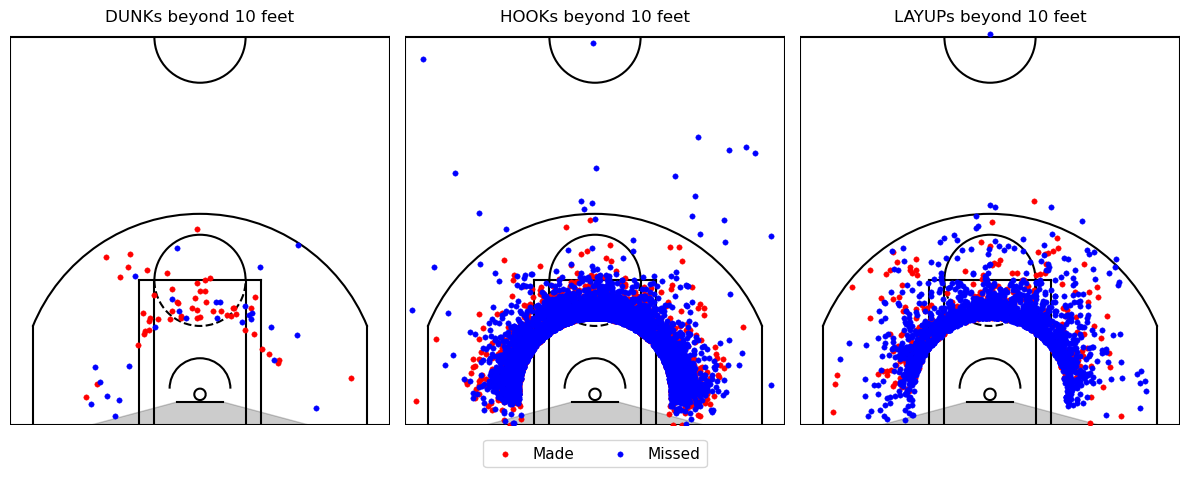

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4.5))
shot_types = ['DUNK', 'HOOK', 'LAYUP']
min_dist = 10
for ax, shot in zip(axes, shot_types):
    draw_court_on_ax(ax)
    mask = (pl.col('shot_type') == shot) & (pl.col('distance') >= min_dist)
    made_mask = mask & (pl.col('is_made') == 1)
    miss_mask = mask & (pl.col('is_made') == 0)
    made_df = df.filter(made_mask)
    miss_df = df.filter(miss_mask)
    ax.scatter(
        made_df['xLegacy'].to_numpy(), 
        made_df['yLegacy'].to_numpy(),
        s=15,
        color='red',
        linewidth=0.3,
        zorder=5,
        label='Made'
    )
    ax.scatter(
        miss_df['xLegacy'].to_numpy(), 
        miss_df['yLegacy'].to_numpy(),
        s=15,
        color='blue',
        linewidth=0.3,
        zorder=5,
        label='Missed'
    )
    ax.set_title(f"{shot}s beyond 10 feet")
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
mask = (pl.col('shot_type') == 'LAYUP') & (pl.col('distance') >= 35)
df.filter(mask).select('description')

description
str
"""MISS Thornton 56' 3PT Running …"
"""MISS Ross 47' Layup"""


In [11]:
df.filter(mask).select('description').row(0)

("MISS Thornton 56' 3PT Running Layup",)

In [12]:
df.filter(mask).select('SEASON').row(0)

('2010-11',)

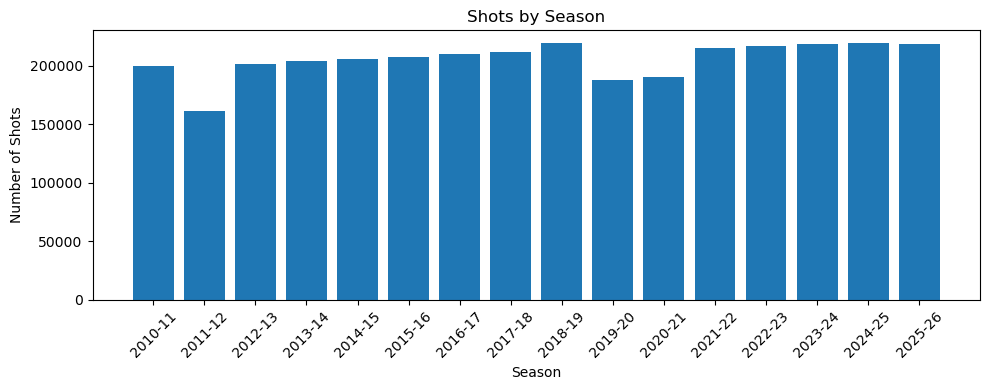

In [13]:
season_counts = df.group_by("SEASON").len().sort("SEASON")
plt.figure(figsize=(10, 4))
plt.bar(
    season_counts["SEASON"].to_list(),
    season_counts["len"].to_list()
)
plt.xlabel("Season")
plt.ylabel("Number of Shots")
plt.title("Shots by Season")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

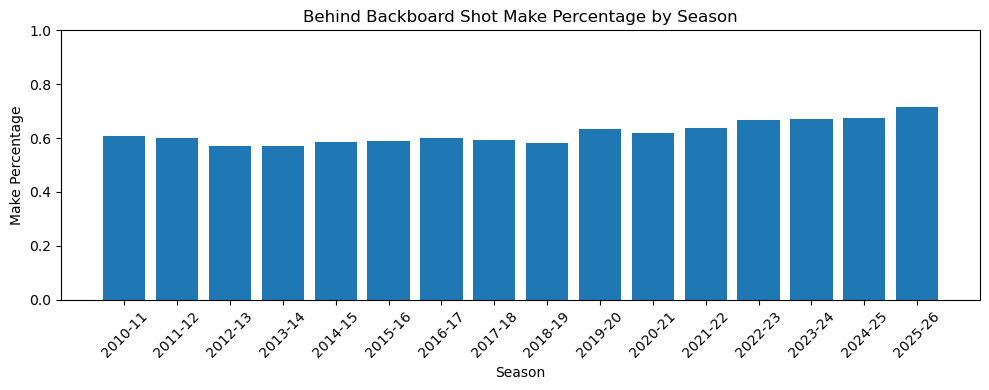

In [14]:
behind_backboard = df.filter(pl.col("is_behind_backboard") == 1).group_by("SEASON").agg(pl.col("is_made").mean().alias("make_pct")).sort("SEASON")
plt.figure(figsize=(10, 4))
plt.bar(
    behind_backboard["SEASON"].to_list(),
    behind_backboard["make_pct"].to_list()
)
plt.xlabel("Season")
plt.ylabel("Make Percentage")
plt.title("Behind Backboard Shot Make Percentage by Season")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

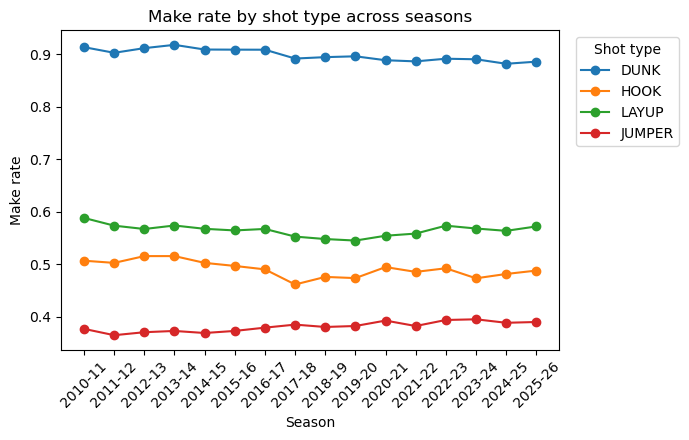

In [15]:
make_rate = df.group_by(['SEASON', 'shot_type']).agg(pl.col('is_made').mean().alias('make_rate')).pivot(index='SEASON', on='shot_type', values='make_rate').sort('SEASON')
fig, ax = plt.subplots(figsize=(7, 4.5))
for shot in ['DUNK', 'HOOK', 'LAYUP', 'JUMPER', 'OTH']:
    if shot in make_rate.columns:
        ax.plot(
            make_rate['SEASON'].to_list(),
            make_rate[shot].to_list(),
            marker='o',
            label=shot
        )

ax.set_xlabel('Season')
ax.set_ylabel('Make rate')
ax.set_title('Make rate by shot type across seasons')
plt.xticks(rotation=45)
ax.legend(title='Shot type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

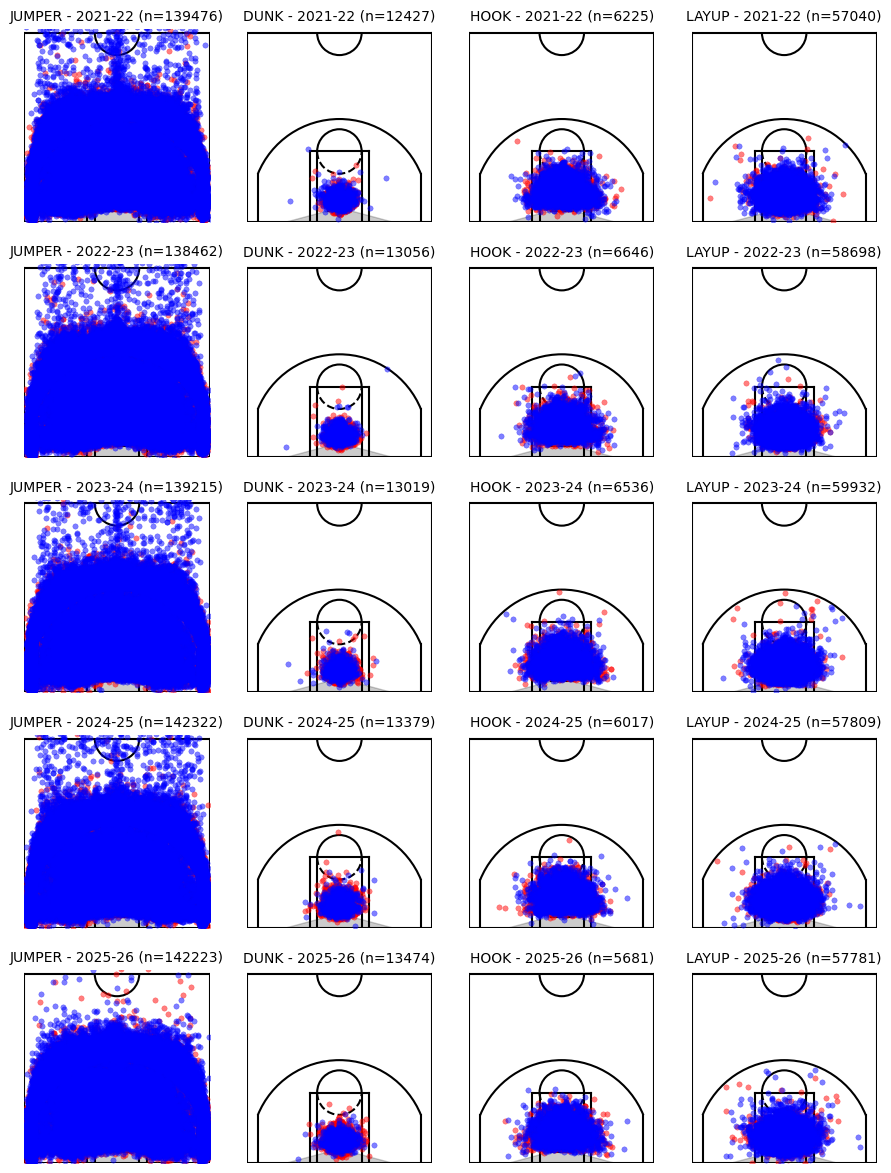

In [16]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(11, 15))
shot_types = ['JUMPER', 'DUNK', 'HOOK', 'LAYUP']
seasons = ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
for i, s in enumerate(seasons):
    for j, shot in enumerate(shot_types):
        ax = axes[i, j]
        draw_court_on_ax(ax)
        made_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 1)
        )
        miss_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 0)
        )
        n_total = made_df.height + miss_df.height
        ax.scatter(
            made_df['xLegacy'].to_numpy(),
            made_df['yLegacy'].to_numpy(),
            s=15, color='red', alpha=0.5, linewidth=0.3, zorder=5, label='Made'
        )
        ax.scatter(
            miss_df['xLegacy'].to_numpy(),
            miss_df['yLegacy'].to_numpy(),
            s=15, color='blue', alpha=0.5, linewidth=0.3, zorder=5, label='Missed'
        )
        ax.set_title(f"{shot} - {s} (n={n_total})", fontsize=10)

plt.subplots_adjust(hspace=0.1)
plt.show()

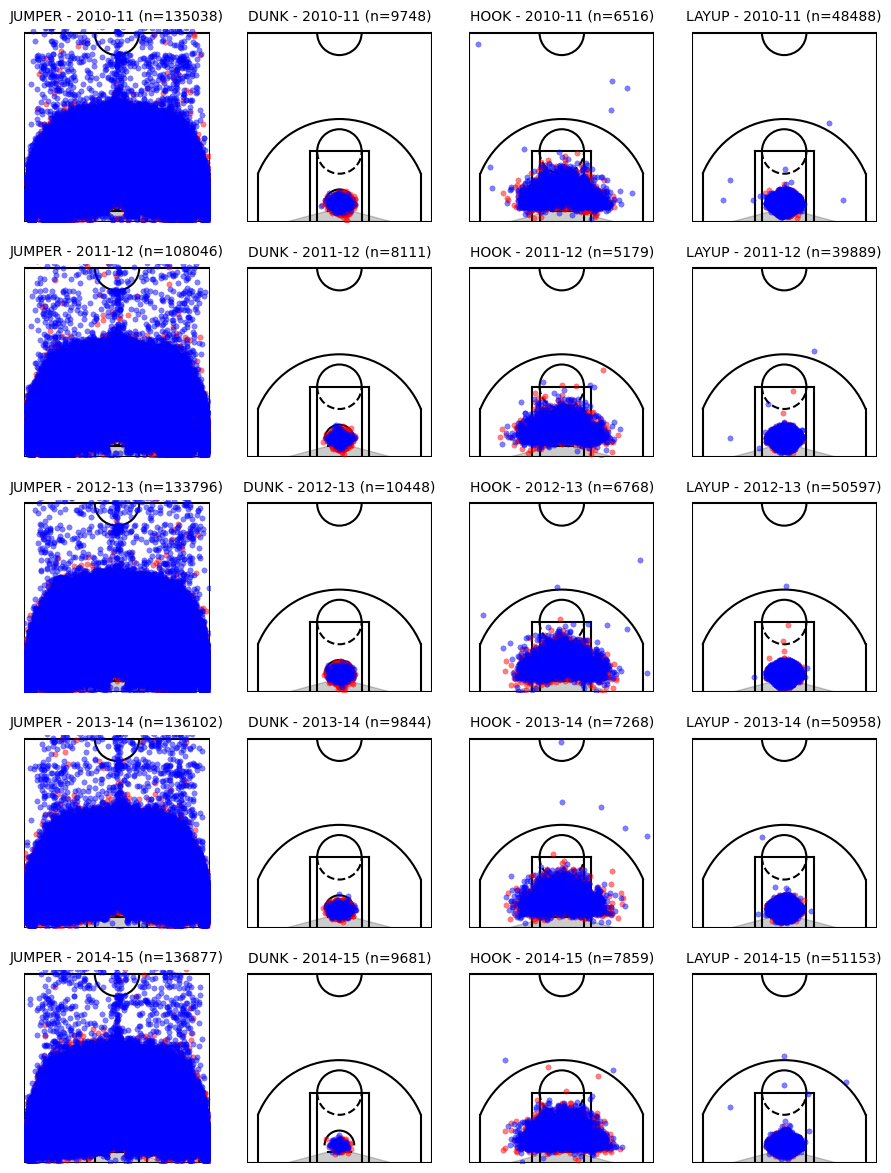

In [17]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(11, 15))
shot_types = ['JUMPER', 'DUNK', 'HOOK', 'LAYUP']
seasons = ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15']
for i, s in enumerate(seasons):
    for j, shot in enumerate(shot_types):
        ax = axes[i, j]
        draw_court_on_ax(ax)
        made_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 1)
        )
        miss_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 0)
        )
        n_total = made_df.height + miss_df.height
        ax.scatter(
            made_df['xLegacy'].to_numpy(),
            made_df['yLegacy'].to_numpy(),
            s=15, color='red', alpha=0.5, linewidth=0.3, zorder=5, label='Made'
        )
        ax.scatter(
            miss_df['xLegacy'].to_numpy(),
            miss_df['yLegacy'].to_numpy(),
            s=15, color='blue', alpha=0.5, linewidth=0.3, zorder=5, label='Missed'
        )
        ax.set_title(f"{shot} - {s} (n={n_total})", fontsize=10)

plt.subplots_adjust(hspace=0.1)
plt.show()

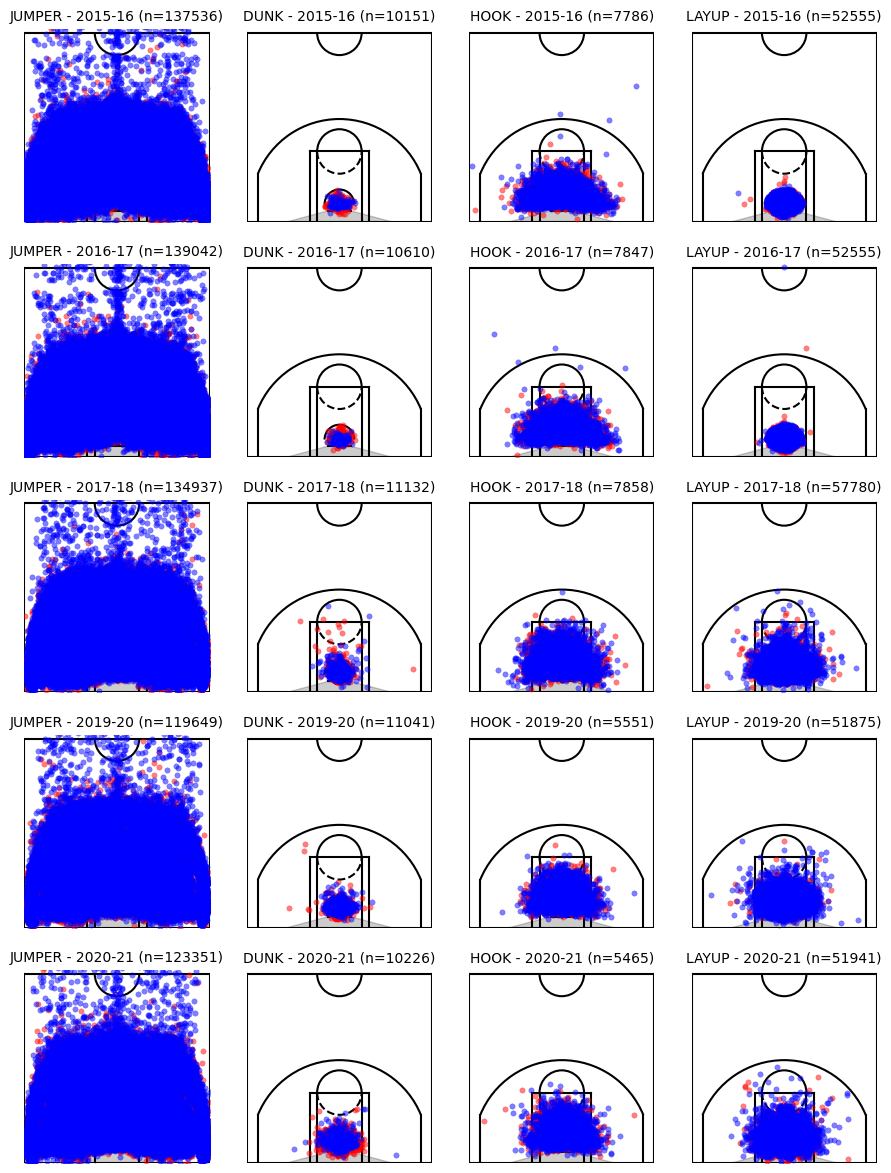

In [18]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(11, 15))
shot_types = ['JUMPER', 'DUNK', 'HOOK', 'LAYUP']
seasons = ['2015-16', '2016-17', '2017-18', '2019-20', '2020-21']
for i, s in enumerate(seasons):
    for j, shot in enumerate(shot_types):
        ax = axes[i, j]
        draw_court_on_ax(ax)
        made_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 1)
        )
        miss_df = df.filter(
            (pl.col('shot_type') == shot) &
            (pl.col('SEASON') == s) &
            (pl.col('is_made') == 0)
        )
        n_total = made_df.height + miss_df.height
        ax.scatter(
            made_df['xLegacy'].to_numpy(),
            made_df['yLegacy'].to_numpy(),
            s=15, color='red', alpha=0.5, linewidth=0.3, zorder=5, label='Made'
        )
        ax.scatter(
            miss_df['xLegacy'].to_numpy(),
            miss_df['yLegacy'].to_numpy(),
            s=15, color='blue', alpha=0.5, linewidth=0.3, zorder=5, label='Missed'
        )
        ax.set_title(f"{shot} - {s} (n={n_total})", fontsize=10)

plt.subplots_adjust(hspace=0.1)
plt.show()

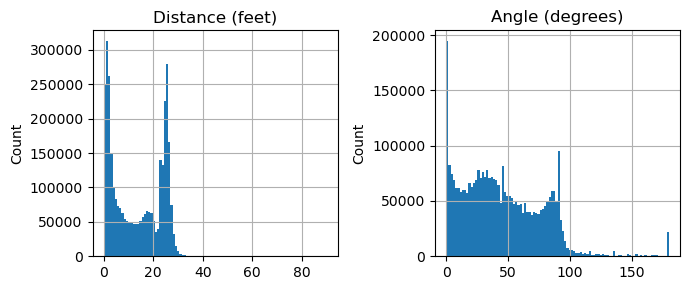

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].hist(df["distance"].to_numpy(), bins=100)
ax[0].set_title("Distance (feet)")
ax[0].set_ylabel("Count")
ax[0].grid(True)
ax[1].hist(df["angle"].to_numpy(), bins=100)
ax[1].set_title("Angle (degrees)")
ax[1].set_ylabel("Count")
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [20]:
sub = df.select(['is_made','distance','angle','shot_type','shot_type_numeric','is_behind_backboard','SEASON'])
sub = sub.drop_nulls()
print(sub.shape)

(3290130, 7)


In [21]:
sub.head()

is_made,distance,angle,shot_type,shot_type_numeric,is_behind_backboard,SEASON
i8,f64,f64,str,i32,i8,str
0,1.17047,19.983107,"""LAYUP""",1,0,"""2010-11"""
1,19.738541,46.84761,"""JUMPER""",0,0,"""2010-11"""
0,18.469976,63.296218,"""JUMPER""",0,0,"""2010-11"""
0,2.213594,71.565051,"""LAYUP""",1,0,"""2010-11"""
0,18.588437,54.856471,"""JUMPER""",0,0,"""2010-11"""


In [22]:
y = sub['is_made']
shot_type=sub['shot_type']
stratify_key=sub['is_made'].cast(pl.Utf8)+'_'+sub['shot_type'].cast(pl.Utf8)+'_'+sub['is_behind_backboard'].cast(pl.Utf8)
X=sub.select(['distance','angle','shot_type_numeric','shot_type','is_behind_backboard'])

# main split
X_train, X_test, y_train, y_test, shot_train, shot_test = train_test_split(
    X, y, shot_type,
    test_size=0.3,
    stratify=stratify_key,
    random_state=RANDOM_SEED
)

# define validation set from train split for hp tuning and monitor loss
stratify_key_train = y_train.cast(pl.Utf8) + '_' + shot_train.cast(pl.Utf8)
X_train, X_val, y_train, y_val, shot_train, shot_val = train_test_split(
    X_train, y_train, shot_train,
    test_size=0.3,
    stratify=stratify_key_train,
    random_state=RANDOM_SEED
)

# define query set from test to compare final performance across models
stratify_key_query = y_test.cast(pl.Utf8) + '_' + shot_test.cast(pl.Utf8)
X_test, X_query, y_test, y_query, shot_test, shot_query = train_test_split(
    X_test, y_test, shot_test,
    test_size=0.5,
    stratify=stratify_key_query,
    random_state=RANDOM_SEED
)

def pipe_data(df:pd.DataFrame, num_cols:List, cat_cols: List, scaler:TransformerMixin, set_name:str) -> Tuple[pd.DataFrame, TransformerMixin]:
    dff = pd.DataFrame(df, columns=num_cols + cat_cols)
    if set_name == 'train':
        dff_mm = scaler.fit_transform(dff[num_cols])
    else:
        dff_mm = scaler.transform(dff[num_cols])

    dff_mm = pd.DataFrame(dff_mm, columns=num_cols, index=dff.index)
    dff_mm[cat_cols] = dff[cat_cols]
    dff_mm['set_name'] = set_name
    return dff_mm, scaler

mm_scaler = MinMaxScaler()
num_cols = ['distance', 'angle']
cat_cols = ['shot_type_numeric', 'shot_type','is_behind_backboard']
X_train_mm, mm_scaler = pipe_data(X_train, num_cols, cat_cols, mm_scaler, 'train')
X_val_mm, _ = pipe_data(X_val, num_cols, cat_cols, mm_scaler, 'val')
X_query_mm, _ = pipe_data(X_query, num_cols, cat_cols, mm_scaler, 'query')
X_test_mm, _ = pipe_data(X_test, num_cols, cat_cols, mm_scaler, 'test')

print(X_train_mm.shape, X_val_mm.shape, X_query_mm.shape, X_test_mm.shape)

(1612163, 6) (690928, 6) (493520, 6) (493519, 6)


In [23]:
agg = pd.concat([X_train_mm,X_val_mm,X_query_mm,X_test_mm])
target_agg = pd.concat([pd.Series(y_train),pd.Series(y_val),pd.Series(y_query),pd.Series(y_test)])
agg['is_made'] = target_agg.values
agg['is_made'] = target_agg
agg.head()

,distance,angle,shot_type_numeric,shot_type,is_behind_backboard,set_name,is_made
0,0.187613,0.195018,0,JUMPER,0,train,0
1,0.029004,0.524437,1,LAYUP,0,train,0
2,0.115727,0.422763,0,JUMPER,0,train,1
3,0.256781,0.472390,0,JUMPER,0,train,1
4,0.109662,0.224862,0,JUMPER,0,train,1


In [24]:
agg.to_csv('shot_probs_data.csv',index=False)

In [25]:
import joblib
joblib.dump(mm_scaler, 'mm_scaler.pkl')

['mm_scaler.pkl']

In [26]:
for i in ['DUNK','JUMPER','HOOK','LAYUP']:
    st = sub.filter(pl.col('shot_type') == i)
    print(f"""{i}: {round(st['is_made'].mean()*100,1)}""")

print((sub['shot_type'].value_counts().with_columns(
    (pl.col('count') / sub.height * 100).round(1).alias('percent')
)))

DUNK: 89.8
JUMPER: 38.1
HOOK: 49.1
LAYUP: 56.4
shape: (4, 3)
┌───────────┬─────────┬─────────┐
│ shot_type ┆ count   ┆ percent │
│ ---       ┆ ---     ┆ ---     │
│ str       ┆ u32     ┆ f64     │
╞═══════════╪═════════╪═════════╡
│ JUMPER    ┆ 2143411 ┆ 65.1    │
│ HOOK      ┆ 107654  ┆ 3.3     │
│ LAYUP     ┆ 859983  ┆ 26.1    │
│ DUNK      ┆ 179082  ┆ 5.4     │
└───────────┴─────────┴─────────┘


In [27]:
for setdf, tar in zip([X_train, X_val], [y_train, y_val]):
    setdf = pd.DataFrame(setdf, columns = num_cols + cat_cols)
    setdf['is_made'] = tar
    print(setdf.shape)
    for i in ['DUNK','JUMPER','HOOK','LAYUP']:
        st = setdf.loc[(setdf['shot_type']==i)]
        print(f"""{i}: {round(np.mean(st['is_made'])*100,1)}""")
    print(round(setdf['shot_type'].value_counts()/len(setdf)*100, 1))

(1612163, 6)
DUNK: 89.8
JUMPER: 38.1
HOOK: 49.1
LAYUP: 56.4
shot_type
JUMPER    65.1
LAYUP     26.1
DUNK       5.4
HOOK       3.3
Name: count, dtype: float64
(690928, 6)
DUNK: 89.8
JUMPER: 38.1
HOOK: 49.1
LAYUP: 56.4
shot_type
JUMPER    65.1
LAYUP     26.1
DUNK       5.4
HOOK       3.3
Name: count, dtype: float64


In [28]:
for setdf, tar in zip([X_query, X_test], [y_query, y_test]):
    setdf = pd.DataFrame(setdf, columns = num_cols + cat_cols)
    setdf['is_made'] = tar
    print(setdf.shape)
    for i in ['DUNK','JUMPER','HOOK','LAYUP']:
        st = setdf.loc[(setdf['shot_type']==i)]
        print(f"""{i}: {round(np.mean(st['is_made'])*100,1)}""")
    print(round(setdf['shot_type_numeric'].value_counts()/len(setdf)*100, 1))

(493520, 6)
DUNK: 89.8
JUMPER: 38.1
HOOK: 49.1
LAYUP: 56.4
shot_type_numeric
0    65.1
1    26.1
2     5.4
3     3.3
Name: count, dtype: float64
(493519, 6)
DUNK: 89.8
JUMPER: 38.1
HOOK: 49.1
LAYUP: 56.4
shot_type_numeric
0    65.1
1    26.1
2     5.4
3     3.3
Name: count, dtype: float64


In [29]:
print(len(sub))

3290130


In [30]:
sub['is_behind_backboard'].mean()*100

0.3450319592234957

In [31]:
sub.filter(pl.col('is_behind_backboard') == 1)['is_made'].mean()*100

60.96723044397463